**Author**: Felipe Matheus  
**Start Date**: 23/07/2026  
**End Date**: 24/07/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor ofelongation after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [43]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from scipy.stats import norm
from autogluon.tabular import TabularPredictor


module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from src.metrics.Evaluation import Evaluation
from src.DataLoader import LoaderHelper

from config.Variables import Variables

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
modl = Modeling()
evla = Evaluation()
varv = Variables()
load = LoaderHelper()


## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [ ]:
# ---- Experiment settings ----
TAG = "notebook_test_11082026"
SCHEMA_DATE = "110826"
VARIABLE = "elongation"

# ---- Paths ----
FILE_NAME = f"dataset_annealing_{VARIABLE}.csv"
FILE_NAME_SCHEMA_DATA = "schema_annealing_essays_{}.csv".format(SCHEMA_DATE)

PROCESS = f"annealing_{VARIABLE}"

# All artifacts of THIS run (predictors included) live under the TAG folder,
# so different experiments never overwrite each other's models.
EXPERIMENT_DIR = os.path.join(varv.PATHS.models, PROCESS, TAG)
os.makedirs(EXPERIMENT_DIR, exist_ok=True)

# ---- Dataset schema ----
TARGET = "elongation_final"
FEATURES = ["initial_diameter", "tensile_strength", "purity", "elongation", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 1

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "medium_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "medium_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of sigma2_aleat as fraction of Var(y), in case of predictions as "100% sure" it still adds  small variance
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

# ---- AGL x H2O comparison ----
USE_SHARED_FOLDS = False           # same fold_id column on both engines
FOLD_SEED = 42

# ---- Physical constraints (inference-time) ----
# Y_MAX = 105.0                     # physical ceiling for %IACS


# 2. Data

## 2.1 Schema data

In [46]:
df, df_val = proc.process_annealing_elongation(
    features=FEATURES,
    target=TARGET,
    df_schema=pd.read_csv(os.path.join(varv.PATHS.data_raw, FILE_NAME_SCHEMA_DATA))
)

In [47]:
df

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final
0,2.160000,391.690000,99.9000,4.90,573.0,30.0,48.60
1,2.182333,387.595254,99.9000,6.02,573.0,30.0,56.21
2,1.200000,431.580000,99.9000,0.94,523.0,30.0,20.15
3,1.200000,431.580000,99.9000,0.94,523.0,60.0,22.04
4,1.200000,431.580000,99.9000,0.94,523.0,90.0,24.62
5,1.200000,431.580000,99.9000,0.94,573.0,30.0,24.72
6,1.200000,431.580000,99.9000,0.94,573.0,60.0,27.43
7,1.200000,431.580000,99.9000,0.94,573.0,90.0,25.24
8,1.200000,431.580000,99.9000,0.94,623.0,30.0,27.06
9,1.200000,431.580000,99.9000,0.94,623.0,60.0,26.17


## 2.2 Validation data

In [48]:
# # ---- Validation data ----
# df_val = proc.load_validation_data_chimie_paris(
#     path=os.path.join(varv.PATHS.data_processed, FILE_NAME_VALIDATION_DATA)
# )


In [49]:
df_val

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final
35,2.0,349.58,99.7637,5.78,723.0,60.0,60.56
13,1.2,397.09,99.9000,2.36,573.0,60.0,42.55
26,0.8,347.70,99.9740,3.56,823.0,0.5,5.67
30,0.8,347.70,99.9740,3.56,873.0,20.0,43.80
16,1.2,397.09,99.9000,2.36,523.0,60.0,44.97
31,0.8,347.70,99.9740,3.56,873.0,30.0,48.53
21,1.2,335.21,99.9800,1.61,523.0,30.0,51.01
12,1.2,397.09,99.9000,2.36,573.0,30.0,44.18
8,1.2,431.58,99.9000,0.94,623.0,30.0,27.06
17,1.2,397.09,99.9000,2.36,523.0,90.0,42.28


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [50]:
df.head(10)

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final
0,2.160000,391.690000,99.9,4.90,573.0,30.0,48.60
1,2.182333,387.595254,99.9,6.02,573.0,30.0,56.21
2,1.200000,431.580000,99.9,0.94,523.0,30.0,20.15
3,1.200000,431.580000,99.9,0.94,523.0,60.0,22.04
4,1.200000,431.580000,99.9,0.94,523.0,90.0,24.62
5,1.200000,431.580000,99.9,0.94,573.0,30.0,24.72
6,1.200000,431.580000,99.9,0.94,573.0,60.0,27.43
7,1.200000,431.580000,99.9,0.94,573.0,90.0,25.24
8,1.200000,431.580000,99.9,0.94,623.0,30.0,27.06
9,1.200000,431.580000,99.9,0.94,623.0,60.0,26.17


In [51]:
df.head(10)

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final
0,2.160000,391.690000,99.9,4.90,573.0,30.0,48.60
1,2.182333,387.595254,99.9,6.02,573.0,30.0,56.21
2,1.200000,431.580000,99.9,0.94,523.0,30.0,20.15
3,1.200000,431.580000,99.9,0.94,523.0,60.0,22.04
4,1.200000,431.580000,99.9,0.94,523.0,90.0,24.62
5,1.200000,431.580000,99.9,0.94,573.0,30.0,24.72
6,1.200000,431.580000,99.9,0.94,573.0,60.0,27.43
7,1.200000,431.580000,99.9,0.94,573.0,90.0,25.24
8,1.200000,431.580000,99.9,0.94,623.0,30.0,27.06
9,1.200000,431.580000,99.9,0.94,623.0,60.0,26.17


In [52]:
predictor_a = modl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(EXPERIMENT_DIR, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    # groups="fold_id" if USE_SHARED_FOLDS else None,
    # sample_weight="weight_col",
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       0.66 GB / 31.57 GB (2.1%)
Disk Space Avail:   729.81 GB / 932.08 GB (78.3%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_elongation\notebook_test_11082026\model_a"
Train Data Rows:    36
Train Data Columns: 6
Label Column:       elongation_final
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (61.1, 5.67, 37.28861, 15.43743)
	If 'reg

KeyboardInterrupt: 

In [ ]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-10.580507,root_mean_squared_error,0.056387,17.287012,0.001017,0.010268,2,True,10
1,NeuralNetTorch_BAG_L1,-11.407716,root_mean_squared_error,0.050259,15.342067,0.050259,15.342067,1,True,8
2,LightGBMLarge_BAG_L1,-11.592158,root_mean_squared_error,0.005111,1.934677,0.005111,1.934677,1,True,9
3,CatBoost_BAG_L1,-11.761759,root_mean_squared_error,0.014096,3.526282,0.014096,3.526282,1,True,4
4,RandomForestMSE_BAG_L1,-12.784209,root_mean_squared_error,0.088996,1.480637,0.088996,1.480637,1,True,3
5,ExtraTreesMSE_BAG_L1,-12.967845,root_mean_squared_error,0.103257,0.731849,0.103257,0.731849,1,True,5
6,XGBoost_BAG_L1,-13.860952,root_mean_squared_error,0.014841,1.772282,0.014841,1.772282,1,True,7
7,LightGBM_BAG_L1,-15.777182,root_mean_squared_error,0.008312,2.991057,0.008312,2.991057,1,True,2
8,LightGBMXT_BAG_L1,-15.777182,root_mean_squared_error,0.009058,1.411963,0.009058,1.411963,1,True,1
9,NeuralNetFastAI_BAG_L1,-15.880245,root_mean_squared_error,0.096341,13.371042,0.096341,13.371042,1,True,6


## 3.1 H2O AutoML Comparison

Quick H2O AutoML run with the same time budget and cross-validation folds as Model A, to benchmark AutoGluon's OOF RMSE against H2O's leader CV RMSE.

In [ ]:
aml_h2o = modl.fit_h2o_automl(
    df= df,
    target= TARGET,
    features= FEATURES,
    weight_on_essay_rows= WEIGHT_ON_ESSAY_ROWS,
    num_bag_folds= NUM_BAG_FOLDS_A,
    use_shared_folds= USE_SHARED_FOLDS,
    time_limit= TIME_LIMIT_A
)

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 24.0.2+12-54, mixed mode, sharing)
  Starting server from C:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\fmfoa\AppData\Local\Temp\tmpfe5w2mfs
  JVM stdout: C:\Users\fmfoa\AppData\Local\Temp\tmpfe5w2mfs\h2o_fmfoa_started_from_python.out
  JVM stderr: C:\Users\fmfoa\AppData\Local\Temp\tmpfe5w2mfs\h2o_fmfoa_started_from_python.err
  Server is running at http://127.0.0.1:54323
Connecting to H2O server at http://127.0.0.1:54323 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,4 months and 30 days
H2O_cluster_name:,H2O_from_python_fmfoa_gl1rii
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.983 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
11:00:02.756: AutoML: XGBoost is not available; skipping it.


11:00:03.527: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 36.0.

███████████████████████████████████████████████████████████████| (done) 100%


In [ ]:
aml_h2o.leaderboard.head(10)

model_id,rmse,mse,mae,rmsle,mean_residual_deviance
GBM_grid_1_AutoML_1_20260811_110002_model_891,10.0528,101.06,6.15879,0.475137,101.06
GBM_grid_1_AutoML_1_20260811_110002_model_1192,10.1579,103.184,5.6017,0.459165,103.184
StackedEnsemble_BestOfFamily_5_AutoML_1_20260811_110002,10.3348,106.809,6.70905,0.472777,106.809
GBM_grid_1_AutoML_1_20260811_110002_model_54,10.4071,108.307,5.96567,0.475075,108.307
GBM_grid_1_AutoML_1_20260811_110002_model_751,10.4136,108.444,5.99442,0.454573,108.444
GBM_grid_1_AutoML_1_20260811_110002_model_537,10.4273,108.728,6.55721,0.49534,108.728
GBM_grid_1_AutoML_1_20260811_110002_model_991,10.5119,110.5,6.14185,0.452351,110.5
GBM_grid_1_AutoML_1_20260811_110002_model_130,10.536,111.008,6.2592,0.463088,111.008
GBM_grid_1_AutoML_1_20260811_110002_model_301,10.5823,111.986,5.69666,0.470529,111.986
GBM_grid_1_AutoML_1_20260811_110002_model_1177,10.692,114.319,6.1287,0.466396,114.319


NOTE: the previous cell here compared AutoGluon's `score_val` against
H2O's xval RMSE.

That comparison is incoherent when sample weights are
active: H2O's xval RMSE is WEIGHTED by weights_column, while AutoGluon's
score_val is UNWEIGHTED unless weight_evaluation=True.

The fair, like-for-like comparison (unweighted metrics on OOF predictions of both
engines, same y_true, same folds when USE_SHARED_FOLDS) is done in
Section 10 ("OOF metrics: AutoGluon vs H2O").


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [ ]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = np.abs(df[TARGET] - mu_oof)
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(36,)  any NaN? False


## 4.1 fast check on big residuals

In [ ]:
df_verification = pd.concat(
    [df[FEATURES + [TARGET]],
     mu_oof.rename(f"{TARGET}_pred"),
     residuals_oof.rename("residual")], axis=1
)

df_verification.sort_values(by="residual")
# 

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final,elongation_final_pred,residual
5,1.200000,431.580000,99.9000,0.94,573.0,30.0,24.72,24.861185,0.141185
7,1.200000,431.580000,99.9000,0.94,573.0,90.0,25.24,25.500248,0.260248
13,1.200000,397.090000,99.9000,2.36,573.0,60.0,42.55,42.865822,0.315822
8,1.200000,431.580000,99.9000,0.94,623.0,30.0,27.06,27.455460,0.395460
20,1.200000,335.210000,99.9800,1.61,573.0,90.0,46.64,47.093044,0.453044
30,0.800000,347.700000,99.9740,3.56,873.0,20.0,43.80,42.759472,1.040528
17,1.200000,397.090000,99.9000,2.36,523.0,90.0,42.28,40.740337,1.539663
9,1.200000,431.580000,99.9000,0.94,623.0,60.0,26.17,28.049732,1.879732
18,1.200000,335.210000,99.9800,1.61,573.0,30.0,45.97,48.189266,2.219266
6,1.200000,431.580000,99.9000,0.94,573.0,60.0,27.43,24.904427,2.525573


## 4.2 Recovering weights 

In [ ]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = modl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (9, 36)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1']


In [ ]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = modl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000002  (OK)

Non-zero weights:
  NeuralNetTorch_BAG_L1           0.5333
  LightGBMLarge_BAG_L1            0.4667


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [ ]:
mu_recomputed, sigma2_epist_oof = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

mu_diffs = np.abs(mu_recomputed - mu_oof)
mu_diffs.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof):.4f}")
# print(f"  max    = {sigma2_epist_oof.max():.4f}")

count    3.600000e+01
mean     7.396870e-07
std      5.435507e-07
min      3.143100e-09
25%      3.670527e-07
50%      5.898653e-07
75%      1.109099e-06
max      1.902241e-06
Name: elongation_final, dtype: float64

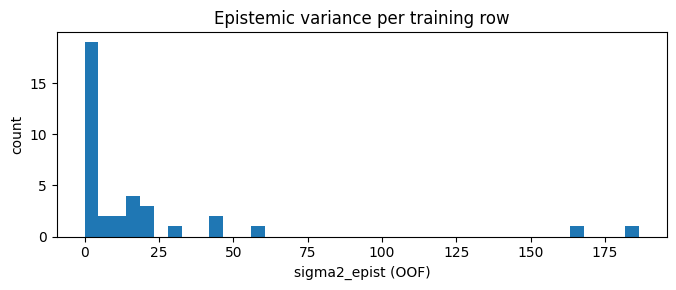

In [ ]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

In [ ]:
mu_recomputed_lin, sigma2_epist_oof_lin = modl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

mu_diffs_lin = np.abs(mu_recomputed_lin - mu_oof)
mu_diffs_lin.describe()
# print("sigma2_epist_oof stats:")
# print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
# print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
# print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

count    36.000000
mean      3.662446
std       3.079227
min       0.300196
25%       1.562096
50%       2.946360
75%       4.630599
max      12.027237
Name: elongation_final, dtype: float64

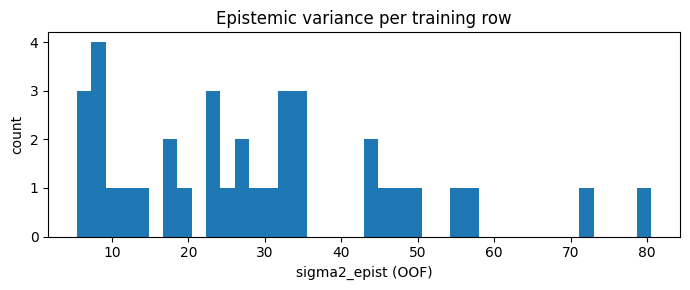

In [ ]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Section 5 Conclusion
When number of lines is at least > 40 

Linear shows way more errors between the recomputed values. Weighted one is corrected.

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [ ]:
r_tilde_sq, residuals_oof_arr, diag = modl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 36
  n_truncated          = 8
  pct_truncated        = 22.22222222222222
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 998.6103371796572
  r_tilde_sq_mean      = 98.32866252984748
  r_tilde_sq_median    = 8.546889913581035


In [ ]:
r_tilde_sq

array([1.36528807e+01, 1.79815025e+01, 7.21991233e+01, 2.28156743e+01,
       8.94099851e+00, 0.00000000e+00, 6.28433731e+00, 2.19503416e-02,
       0.00000000e+00, 1.54630654e+00, 3.89401993e-01, 7.91789815e+00,
       4.85587127e+00, 0.00000000e+00, 9.40752033e+00, 2.99449898e+00,
       9.17977822e+00, 0.00000000e+00, 3.48746356e+00, 8.15278131e+00,
       0.00000000e+00, 2.32262332e+01, 1.16943578e+01, 1.45106694e+01,
       0.00000000e+00, 6.99310546e+01, 9.98610337e+02, 6.41976222e+02,
       4.14061332e+02, 3.57686667e+01, 0.00000000e+00, 0.00000000e+00,
       1.25670575e+02, 9.26113401e+02, 8.06145104e+01, 7.82650452e+00])

# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [ ]:
predictor_b = modl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(EXPERIMENT_DIR, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       4.17 GB / 31.57 GB (13.2%)
Disk Space Avail:   726.82 GB / 932.08 GB (78.0%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_elongation\notebook_test_11082026\model_b"
Train Data Rows:    36
Train Data Columns: 6
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (6.906364650686321, -13.815510557964274, -0

In [ ]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-6.821209,root_mean_squared_error,0.064164,11.048583,0.000000,0.011651,2,True,10
1,XGBoost_BAG_L1,-6.904940,root_mean_squared_error,0.016444,0.825093,0.016444,0.825093,1,True,7
2,CatBoost_BAG_L1,-7.069124,root_mean_squared_error,0.005171,1.621991,0.005171,1.621991,1,True,4
3,NeuralNetTorch_BAG_L1,-7.151528,root_mean_squared_error,0.042549,8.589848,0.042549,8.589848,1,True,8
4,LightGBMLarge_BAG_L1,-7.277316,root_mean_squared_error,0.003983,1.117913,0.003983,1.117913,1,True,9
5,NeuralNetFastAI_BAG_L1,-7.307342,root_mean_squared_error,0.047037,9.384143,0.047037,9.384143,1,True,6
6,LightGBM_BAG_L1,-7.308490,root_mean_squared_error,0.004512,1.036231,0.004512,1.036231,1,True,2
7,LightGBMXT_BAG_L1,-7.308490,root_mean_squared_error,0.005034,1.201448,0.005034,1.201448,1,True,1
8,ExtraTreesMSE_BAG_L1,-8.023787,root_mean_squared_error,0.071095,0.562200,0.071095,0.562200,1,True,5
9,RandomForestMSE_BAG_L1,-8.283290,root_mean_squared_error,0.064552,0.574556,0.064552,0.574556,1,True,3


In [ ]:
df_verification_b = pd.concat(
    [df_verification,
     pd.Series(sigma2_epist_oof, index=df_verification.index, name="epistemic_error"),
     predictor_b.predict_oof().rename("predict_random_error"),
    ], axis=1
)
df_verification_b

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final,elongation_final_pred,residual,epistemic_error,predict_random_error
0,2.160000,391.690000,99.9000,4.90,573.0,30.0,48.60,52.723835,4.123835,3.353134,-0.657074
1,2.182333,387.595254,99.9000,6.02,573.0,30.0,56.21,50.598751,5.611249,13.504612,-0.932606
2,1.200000,431.580000,99.9000,0.94,523.0,30.0,20.15,29.446968,9.296968,14.234492,-0.651244
3,1.200000,431.580000,99.9000,0.94,523.0,60.0,22.04,26.877619,4.837619,0.586881,0.628834
4,1.200000,431.580000,99.9000,0.94,523.0,90.0,24.62,29.510519,4.890519,14.976178,-1.101912
5,1.200000,431.580000,99.9000,0.94,573.0,30.0,24.72,24.861185,0.141185,0.957635,-0.949076
6,1.200000,431.580000,99.9000,0.94,573.0,60.0,27.43,24.904427,2.525573,0.094184,-1.313176
7,1.200000,431.580000,99.9000,0.94,573.0,90.0,25.24,25.500248,0.260248,0.045779,-1.055373
8,1.200000,431.580000,99.9000,0.94,623.0,30.0,27.06,27.455460,0.395460,0.507695,-0.967770
9,1.200000,431.580000,99.9000,0.94,623.0,60.0,26.17,28.049732,1.879732,1.987087,-0.973111


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

Real coverage considering sigmas calculated so far

Build the predictive distribution. Not totally OOF cause model b is not generating OOF preds, we assume it's optimistic just a bit too small to be considered.


In [ ]:
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = modl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = modl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
cal_before

=== Calibration BEFORE recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.222222,-0.277778
1,0.80,0.444444,-0.355556
2,0.90,0.611111,-0.288889
3,0.95,0.750000,-0.200000


Fit a scalar recalibration factor to pull coverage using α=0.9 as nominal reference


In [ ]:
c_opt = modl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = modl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
cal_after

Recalibration scalar c = 2.0451

=== Calibration AFTER recalibration ===


,alpha,empirical_coverage,gap
0,0.50,0.472222,-0.027778
1,0.80,0.833333,0.033333
2,0.90,0.888889,-0.011111
3,0.95,0.888889,-0.061111


# 8.1 Validation Set Evaluation

Evaluate the freshly trained pair (A + B, with the recalibration $c$) on a
validation DataFrame.

`modl.predict_target` is target-agnostic: it accepts a DataFrame **or a dict**
and any AutoGluon predictor (IACS, UTS, Model B...), inferring the features
from the predictor when not given.

In [ ]:
c_opt
weights

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.53333335, 0.46666665])

In [ ]:
len(base_model_names)
len(weights)

9

In [ ]:
# ---- Validation set: df_schema (illustrative; in-sample, see caveat) ----
# df_val = df_schema.copy()

# Full calibrated predictive distribution on the validation set.
preds_val = modl.predict_with_uncertainty(
    X=df.copy(), # df_schema.copy()
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,
)

val_metrics = evla.metrics_on_dataframe(
    df=df.copy(), #df_schema.copy()
    target=TARGET,
    mu=preds_val["mu"].to_numpy(),
    sigma=preds_val["sigma_total"].to_numpy(),
    alphas=CALIBRATION_ALPHAS,
)
print("=== Validation metrics (df_schema) ===")
print({k: round(v, 4) for k, v in val_metrics.items() if k != "coverage"})
print("coverage:", {a: round(c, 3) for a, c in val_metrics["coverage"].items()})

=== Validation metrics (df_schema) ===
{'rmse': 8.922, 'mae': 5.3757, 'mape': 48.4067, 'r2': 0.6564}
coverage: {0.5: 0.556, 0.8: 0.833, 0.9: 0.917, 0.95: 0.972}


In [ ]:
# # ---- Target-agnostic point prediction from a plain dict ----
# single = modl.predict_target(
#     predictor_a,
#     {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
# )
# print(f"Predicted {TARGET}: {single[0]:.3f}")

# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [ ]:
df.head(5)

,initial_diameter,tensile_strength,purity,elongation,temperature,time,elongation_final
0,2.160000,391.690000,99.9,4.90,573.0,30.0,48.60
1,2.182333,387.595254,99.9,6.02,573.0,30.0,56.21
2,1.200000,431.580000,99.9,0.94,523.0,30.0,20.15
3,1.200000,431.580000,99.9,0.94,523.0,60.0,22.04
4,1.200000,431.580000,99.9,0.94,523.0,90.0,24.62


In [ ]:
# Fit the OOD reference on the training inputs (stored in artifacts later).
ood_ref = modl.fit_ood_reference(df, features=FEATURES)

preds = modl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
    y_max=Y_MAX,          # physical ceiling -> mu_trunc / sigma_trunc / p_above_max
    ood_ref=ood_ref,      # inputs outside training cloud get inflated sigma
)
preds


,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,48.057291,0.012161,2.383143,10.018096,3.165138,48.057289,1.0,48.057291,3.165138,0.0
1,50.475077,2.092425,2.383143,18.718571,4.326496,50.475079,1.0,50.475077,4.326496,0.0
2,25.157679,1.416955,2.383143,15.893490,3.986664,25.157679,1.0,25.157679,3.986664,0.0
3,25.872678,0.038557,2.383143,10.128492,3.182529,25.872679,1.0,25.872678,3.182529,0.0
4,26.339751,0.079793,2.383143,10.300957,3.209510,26.339750,1.0,26.339751,3.209510,0.0


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [ ]:
# ---- Experiment artifacts (everything under EXPERIMENT_DIR / TAG) ----
artifacts_path = os.path.join(EXPERIMENT_DIR, "artifacts.pkl")

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
    "y_max": Y_MAX,
    "ood_ref": ood_ref,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")


Saved to: ../../models/annealing_elongation\notebook_test_11082026\artifacts.pkl


In [ ]:
# ---- Save global configuration (1.1) as YAML for this experiment (TAG) ----
global_config = {
    "TAG": TAG,
    "SCHEMA_DATE": SCHEMA_DATE,
    "varv.PATHS.data_raw": varv.PATHS.data_raw,
    "varv.PATHS.models": varv.PATHS.models,
    "FILE_NAME": FILE_NAME,
    "FILE_NAME_SCHEMA_DATA": FILE_NAME_SCHEMA_DATA,
    "PROCESS": PROCESS,
    "TARGET": TARGET,
    "FEATURES": FEATURES,
    "WEIGHT_ON_ESSAY_ROWS": WEIGHT_ON_ESSAY_ROWS,
    "PRESETS_A": PRESETS_A,
    "NUM_BAG_FOLDS_A": NUM_BAG_FOLDS_A,
    "NUM_BAG_SETS_A": NUM_BAG_SETS_A,
    "NUM_STACK_LEVELS_A": NUM_STACK_LEVELS_A,
    "TIME_LIMIT_A": TIME_LIMIT_A,
    "PRESETS_B": PRESETS_B,
    "NUM_BAG_FOLDS_B": NUM_BAG_FOLDS_B,
    "NUM_STACK_LEVELS_B": NUM_STACK_LEVELS_B,
    "TIME_LIMIT_B": TIME_LIMIT_B,
    "USE_WEIGHTED_VARIANCE": USE_WEIGHTED_VARIANCE,
    "VARIANCE_FLOOR_FRAC": VARIANCE_FLOOR_FRAC,
    "CALIBRATION_ALPHAS": list(CALIBRATION_ALPHAS),
    "RECALIBRATION_TARGET_ALPHA": RECALIBRATION_TARGET_ALPHA,
    "USE_SHARED_FOLDS": USE_SHARED_FOLDS,
    "FOLD_SEED": FOLD_SEED,
    "Y_MAX": Y_MAX,
}

config_path = os.path.join(EXPERIMENT_DIR, "global_config.txt")
with open(config_path, "w") as f:
    yaml.dump(global_config, f, default_flow_style=False, sort_keys=False)

print(f"Saved to: {config_path}")


Saved to: ../../models/annealing_elongation\notebook_test_11082026\global_config.txt


In [ ]:
# ---- OOF metrics: AutoGluon (Model A leader) vs H2O AutoML leader ----
# Both vectors are out-of-fold predictions; metrics are UNWEIGHTED on both
# sides, and with USE_SHARED_FOLDS=True the folds are identical -> coherent.
h2o_oof_preds = (
    aml_h2o.leader.cross_validation_holdout_predictions()
    .as_data_frame()
    .iloc[:, 0]
    .to_numpy()
)

metrics_agl = evla.one_step_metrics(y_true=y_true, mu=mu_oof.values)
metrics_h2o = evla.one_step_metrics(y_true=y_true, mu=h2o_oof_preds)

metrics_df = pd.DataFrame(
    [
        {"model": "AutoGluon (Model A, leader)", **metrics_agl},
        {"model": "H2O AutoML (leader)", **metrics_h2o},
    ]
)[["model", "rmse", "mae", "mape", "r2"]]

print(metrics_df)

# ---- Leaderboards from both engines ----
leaderboard_agl = predictor_a.leaderboard(silent=True)
leaderboard_h2o = aml_h2o.leaderboard.as_data_frame()

# ---- Save everything for this experiment (TAG) into separate CSV files ----
metrics_df.to_csv(os.path.join(EXPERIMENT_DIR, "metrics_comparison.csv"), index=False)
leaderboard_agl.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_autogluon.csv"), index=False)
leaderboard_h2o.to_csv(os.path.join(EXPERIMENT_DIR, "leaderboard_h2o.csv"), index=False)

print(f"Saved to: {EXPERIMENT_DIR}")


                         model       rmse       mae       mape        r2
0  AutoGluon (Model A, leader)  10.580507  6.734315  57.586612  0.516833
1          H2O AutoML (leader)  10.052847  6.158793  47.492388  0.563823
Saved to: ../../models/annealing_elongation\notebook_test_11082026


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


# 11. Load Artifacts & Predict (deployment simulation)

This section simulates a fresh process: it loads ONLY what was persisted in
Section 10 (`artifacts.pkl`) plus the two AutoGluon predictors from disk —
no variable from the training session above is reused. This is exactly what a
deployment script (or the MBC controller) would do. The same
`predict_with_uncertainty` call as Section 9 runs, but every ingredient
(`weights`, `recalibration_c`, `ood_ref`, `y_max`, ...) comes from the
reloaded artifacts, proving the persisted bundle is self-contained.

In [ ]:

# ---- 1) Load the persisted artifact bundle (Section 10) ----
loaded_artifacts = load.load_pickle(EXPERIMENT_DIR, "artifacts.pkl")

# ---- 2) Reload both AutoGluon predictors from their TAG subfolders ----
predictor_a_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_a")
)
predictor_b_loaded = TabularPredictor.load(
    os.path.join(EXPERIMENT_DIR, "model_b")
)

print("Loaded artifacts keys:", list(loaded_artifacts.keys()))
print("Target:", loaded_artifacts["target"])
print("Features:", loaded_artifacts["features"])

Loaded artifacts keys: ['features', 'target', 'base_model_names', 'weights', 'variance_floor', 'recalibration_c', 'use_weighted_variance', 'calibration_before', 'calibration_after', 'y_max', 'ood_ref']
Target: elongation_final
Features: ['initial_diameter', 'tensile_strength', 'purity', 'elongation', 'temperature', 'time']


In [ ]:
# ---- 3) Predict using ONLY the reloaded objects ----
# Build a small query frame (here: first rows of df, but in deployment this
# would be a brand-new candidate route from the controller).
X_query = df.head(5)

preds_loaded = modl.predict_with_uncertainty(
    X=X_query,
    predictor_a=predictor_a_loaded,
    predictor_b=predictor_b_loaded,
    weights=loaded_artifacts["weights"],
    model_names=loaded_artifacts["base_model_names"],
    features=loaded_artifacts["features"],
    variance_floor=loaded_artifacts["variance_floor"],
    recalibration_c=loaded_artifacts["recalibration_c"],
    use_weights=loaded_artifacts["use_weighted_variance"],
    y_max=loaded_artifacts["y_max"],
    ood_ref=loaded_artifacts["ood_ref"],
)
preds_loaded

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total,leader_model_prediction,ood_multiplier,mu_trunc,sigma_trunc,p_above_max
0,48.057291,0.012161,2.383143,10.018096,3.165138,48.057289,1.0,48.057291,3.165138,0.0
1,50.475077,2.092425,2.383143,18.718571,4.326496,50.475079,1.0,50.475077,4.326496,0.0
2,25.157679,1.416955,2.383143,15.893490,3.986664,25.157679,1.0,25.157679,3.986664,0.0
3,25.872678,0.038557,2.383143,10.128492,3.182529,25.872679,1.0,25.872678,3.182529,0.0
4,26.339751,0.079793,2.383143,10.300957,3.209510,26.339750,1.0,26.339751,3.209510,0.0


In [ ]:
# # ---- 4) Target-agnostic quick prediction from a plain dict ----
# # Works for any predictor/target via modl.predict_target (features inferred
# # from the predictor when not passed explicitly).
# single_loaded = modl.predict_target(
#     predictor_a_loaded,
#     {"initial_diameter": 1.5, "purity": 99.9, "iacs": 88.26, "temperature": 623.0, "time": 60.0},
#     features=loaded_artifacts["features"],
# )
# print(f"Predicted {loaded_artifacts['target']}: {single_loaded[0]:.3f}")

In [ ]:
# ---- 5) Sanity check: reloaded predictions match the in-session ones ----
# (Section 9 computed `preds` on df.head(5) with the same ood_ref/c_opt.)
import numpy as np
if "preds" in dir():
    max_mu_diff = float(np.abs(preds["mu"].to_numpy()
                               - preds_loaded["mu"].to_numpy()).max())
    max_sigma_diff = float(np.abs(preds["sigma_total"].to_numpy()
                                  - preds_loaded["sigma_total"].to_numpy()).max())
    print(f"max |mu diff|    = {max_mu_diff:.2e}")
    print(f"max |sigma diff| = {max_sigma_diff:.2e}")
    print("OK: artifacts reproduce the in-session pipeline."
          if max(max_mu_diff, max_sigma_diff) < 1e-8
          else "WARNING: mismatch - check that Section 9 used the same ood_ref.")
else:
    print("Run Section 9 first to enable the sanity check.")

max |mu diff|    = 0.00e+00
max |sigma diff| = 0.00e+00
OK: artifacts reproduce the in-session pipeline.
